#Customer Segmentation of Credit Card Users Using Machine Learning

In this project, I use machine learning clustering algorithms to analyze the spending behavior of credit card users. By applying algorithms such as K-Means Clustering, I segment customers based on transaction patterns, purchase frequency, cash advances, and credit usage. The resulting clusters reveal distinct customer groups, providing insights for better risk assessment and targeted financial strategies.

# About Data

CUST_ID : Identification of Credit Card holder (Categorical)

BALANCE : Balance amount left in their account to make purchases (
BALANCE_FREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)

PURCHASES : Amount of purchases made from account

ONEOFF_PURCHASES : Maximum purchase amount done in one-go

INSTALLMENTS_PURCHASES : Amount of purchase done in installment

CASH_ADVANCE : Cash in advance given by the user

PURCHASES_FREQUENCY : How frequently the Purchases are being made, score
between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)

ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)

PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)

CASHADVANCEFREQUENCY : How frequently the cash in advance being paid

CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
PURCHASES_TRX : Numbe of purchase transactions made

CREDIT_LIMIT : Limit of Credit Card for user

PAYMENTS : Amount of Payment done by user

MINIMUM_PAYMENTS : Minimum amount of payments made by user

PRCFULLPAYMENT : Percent of full payment paid by user

TENURE : Tenure of credit card service for user

---
### 📦 Step 1 — Import Libraries

This cell loads every external Python library the project depends on. All imports are grouped at the top so dependencies are visible at a glance and errors surface immediately before any analysis begins.

| Library | Role in This Project |
|---|---|
| `pandas` | Loads the CSV, manages the 18-column DataFrame, fills missing values, and produces the final clustered output |
| `numpy` | Powers numerical operations — array indexing, `argmax` for best-k selection, and float conversion before scaling |
| `matplotlib.pyplot` | Renders all charts: elbow curve, silhouette line plot, PCA scatter plot, histograms, boxplots, and bar charts |
| `seaborn` | Produces the correlation heatmap with annotated values; also sets the global `whitegrid` aesthetic for all plots |
| `sklearn.preprocessing.StandardScaler` | Normalizes all 17 numeric features to mean=0, std=1 so no single feature dominates distance calculations |
| `sklearn.cluster.KMeans` | The core clustering algorithm — partitions 8,950 customers into K groups by minimizing within-cluster sum of squares |
| `sklearn.decomposition.PCA` | Compresses 17 scaled dimensions down to 2 principal components for the final scatter plot visualization |
| `scipy.cluster.hierarchy` | Provides `linkage` and `dendrogram` functions — imported here for optional hierarchical comparison |
| `sklearn.cluster.AgglomerativeClustering` | Imported alongside KMeans for potential hierarchical clustering experiments |
| `sklearn.metrics.silhouette_score` | Quantifies cluster quality (range −1 to +1) — used both during K selection and for final model evaluation |
| `warnings.filterwarnings('ignore')` | Suppresses non-critical convergence and deprecation warnings that would otherwise clutter the output |

> 💡 The `random_state=42` used throughout the notebook ensures every run produces identical results — critical for reproducibility in academic and business settings.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')  # hide harmless warnings

#Load the Dataset

---
### 📂 Step 2 — Load Dataset

```python
df = pd.read_csv('...CC GENERAL.csv')
```

This cell reads the raw credit card dataset from Google Drive into a pandas DataFrame named `df`.

- `pd.read_csv()` automatically detects column headers and infers data types for all 18 columns
- The path points to a **Google Colab–mounted Drive location** — update this to a local path when running outside Colab:
  ```python
  df = pd.read_csv('CC GENERAL.csv')
  ```
- After loading, `df` contains **8,950 rows × 18 columns**, each row representing one unique credit card holder
- The 18 features cover balance, purchase behavior, cash advance usage, payment patterns, credit limit, and tenure

> ⚠️ The double forward-slash `//content/...` at the start of the path is non-standard but harmless on Colab — Python treats it as a root path.


In [2]:
#Load the Data

df = pd.read_csv('//content/drive/MyDrive/Colab Notebooks/K-Means Clustering Assignment Creditcard/CC GENERAL.csv')

#Explore & Visualize Data

---
### 🔍 Step 3 — Exploratory Data Analysis (EDA)

The next several cells systematically inspect the dataset's structure, content, quality, and statistical properties before any preprocessing or modeling.

---

#### `df.head(10)` — Preview First 10 Rows

Displays the first 10 rows of the DataFrame, giving an immediate visual overview of:
- The exact column names (with spacing and capitalization used in later code)
- Sample values for each feature — revealing scales (e.g., `BALANCE` in thousands, `TENURE` as small integers)
- The `CUST_ID` column format (e.g., `C10001`) — later confirmed as non-numeric and dropped before modeling


In [3]:
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


#### `df.info()` — Column Types and Non-Null Counts

Prints a compact summary of the DataFrame including:
- **Column names** and their **dtypes** (`float64` for most numeric features, `object` for `CUST_ID`)
- **Non-null counts** per column — immediately flags that `CREDIT_LIMIT` and `MINIMUM_PAYMENTS` have missing entries
- **Memory usage** of the loaded DataFrame

This is the first signal that **missing value handling is required** before K-Means can run (which fails on `NaN` values).


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

#### `df.describe()` — Descriptive Statistics

Generates a statistical summary table for all numeric columns, showing:

| Statistic | What It Tells Us |
|---|---|
| `count` | Confirms which columns have missing values (count < 8950) |
| `mean` | Average customer behavior per feature |
| `std` | Standard deviation — high std relative to mean signals heavy outliers |
| `min / max` | Extreme values — e.g., `PURCHASES` max in the tens of thousands vs. mean ~$1,000 |
| `25% / 50% / 75%` | Quartile spread — shows skew and tail behavior |

> 📌 Key insight: The massive difference in scale between features (e.g., `BALANCE` in thousands vs. `PURCHASES_FREQUENCY` between 0–1) immediately confirms why **StandardScaler is mandatory** before K-Means.


In [5]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


#### `df.shape` — Dataset Dimensions

Returns `(8950, 18)` — confirming the dataset has **8,950 customer records** across **18 columns**.

A quick sanity check that the full file loaded without truncation. The comment in the cell `# 8950 Customers, 18 Columns` serves as an inline assertion.


In [6]:
df.shape   # 8950 Customes, 18 Columns

(8950, 18)

#### `df.dtypes` — Data Type Inspection

Prints the data type of every column individually.

- Confirms `CUST_ID` is `object` (string) — non-numeric, must be dropped before scaling
- All behavioral features are `float64` — ready for numeric operations
- Identifies any unexpected type mismatches that would cause downstream errors

> 💡 If any numeric column appears as `object`, it likely contains string placeholders or formatting issues that need conversion — as will happen with `CREDIT_LIMIT` and `MINIMUM_PAYMENTS` after the initial NaN fill.


In [7]:
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


#Explore and Visulize the Data

---
#### `df.isnull().sum()` — Missing Value Audit

Counts `NaN` values in every column. Results for this dataset:

| Column | Missing Values |
|---|---|
| `CREDIT_LIMIT` | **1** missing |
| `MINIMUM_PAYMENTS` | **313 missing** (~3.5% of data) |
| All other columns | 0 |

This pinpoints exactly where data cleaning is needed. K-Means will throw an error if any `NaN` values remain in the input matrix.


In [8]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


# CREDIT_LIMIT: 1 missing, MINIMUM_PAYMENTS: 313 missing

---
#### `df['CREDIT_LIMIT'].unique()` — Inspect Unique Values

Displays every distinct value in `CREDIT_LIMIT` to understand what the column contains before filling missing values.

- Reveals the range of credit limit values (e.g., 50.0 to 30,000.0)
- Confirms the column is numeric (float) — appropriate for median imputation
- Helps verify no existing string values or encoding issues before the `fillna` step


In [9]:
#remove missing values
df['CREDIT_LIMIT'].unique()

array([ 1000.      ,  7000.      ,  7500.      ,  1200.      ,
        1800.      , 13500.      ,  2300.      , 11000.      ,
        2000.      ,  3000.      ,  8000.      ,  2500.      ,
       13000.      ,  4000.      , 11250.      ,  9000.      ,
        6000.      ,  1700.      , 10500.      ,  6900.      ,
        5000.      ,  4500.      ,  1500.      ,  8500.      ,
        2400.      ,  4200.      ,  3300.      , 12000.      ,
        3500.      ,  6500.      ,  1600.      ,  4150.      ,
        1850.      ,  6250.      ,  2250.      ,  9500.      ,
       16500.      ,  5700.      ,  5500.      , 17000.      ,
        3200.      , 19000.      ,  2800.      , 18000.      ,
       21500.      , 10000.      , 20000.      ,  7900.      ,
       15000.      , 12500.      , 14000.      ,  5300.      ,
         900.      ,  6150.      , 11500.      , 23000.      ,
        2700.      , 14500.      , 19500.      ,  1400.      ,
        2900.      ,  1950.      ,  7200.      , 10950.

#### `df['CREDIT_LIMIT'].fillna('no_CREDIT_LIMIT')` — Preview Fill (No Assignment)

This line **previews** the result of filling `NaN` with the string `'no_CREDIT_LIMIT'` — but does **not** modify the DataFrame because the result is not assigned back.

> ⚠️ Note: Filling a numeric column with a string placeholder (`'no_CREDIT_LIMIT'`) converts the column dtype from `float64` to `object`. This is a **temporary intermediate approach** — the next preprocessing block converts it back to numeric and replaces with the median. This two-step design shows the exploratory thought process.


In [10]:
df['CREDIT_LIMIT'].fillna('no_CREDIT_LIMIT')

,CREDIT_LIMIT
0,1000.0
1,7000.0
2,7500.0
3,7500.0
4,1200.0
...,...
8945,1000.0
8946,1000.0
8947,1000.0
8948,500.0


#### `df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna('no_CREDIT_LIMIT')` — Apply the Fill

Assigns the filled result back to `df['CREDIT_LIMIT']`, replacing the 1 `NaN` value with the string `'no_CREDIT_LIMIT'`.

- This temporarily makes the column dtype `object`
- The string placeholder acts as a visible marker — making it easy to confirm the fill worked
- Later in Step 5, this is corrected: the column is converted back to `float64` with `pd.to_numeric(..., errors='coerce')` and the true median is applied


In [11]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna('no_CREDIT_LIMIT')

#### `df.isnull().sum()` (Second Check) — Verify CREDIT_LIMIT Fill

Re-runs the null check to confirm `CREDIT_LIMIT` now shows 0 missing values after the fill.

- Acts as a **checkpoint** — validates the previous step worked correctly
- `MINIMUM_PAYMENTS` still shows 313 missing at this point (handled in the next two cells)


In [12]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


#### `df['MINIMUM_PAYMENTS'].unique()` — Inspect Minimum Payments Values

Displays all distinct values in `MINIMUM_PAYMENTS` before filling its 313 missing entries.

- Shows the range of payment amounts
- Confirms the column is numeric — valid for statistical imputation
- Informs the choice of fill strategy (median vs. mean)


In [13]:
df['MINIMUM_PAYMENTS'].unique()

array([ 139.509787, 1072.340217,  627.284787, ...,   82.418369,
         55.755628,   88.288956])

#### `df['MINIMUM_PAYMENTS'].fillna('no_MINIMUM_PAYMENTS')` — Preview Fill

Same pattern as `CREDIT_LIMIT` — previews the string fill result **without** modifying the DataFrame.

This preview-then-assign pattern is a common exploratory habit: inspect the transformation output before committing it.


In [14]:
df['MINIMUM_PAYMENTS'].fillna('no_MINIMUM_PAYMENTS')

,MINIMUM_PAYMENTS
0,139.509787
1,1072.340217
2,627.284787
3,no_MINIMUM_PAYMENTS
4,244.791237
...,...
8945,48.886365
8946,no_MINIMUM_PAYMENTS
8947,82.418369
8948,55.755628


#### `df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna('no_MINIMUM_PAYMENTS')` — Apply Fill

Assigns the fill back to the DataFrame, replacing all 313 `NaN` entries in `MINIMUM_PAYMENTS` with the string placeholder `'no_MINIMUM_PAYMENTS'`.

- Temporarily converts column dtype to `object`
- The true numeric median imputation happens in the preprocessing block (Step 5) where both columns are properly handled together


In [15]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna('no_MINIMUM_PAYMENTS')

#### `df.isnull().sum()` (Final EDA Check) — Confirm All Nulls Cleared

Third and final null check in the EDA section. At this point both `CREDIT_LIMIT` and `MINIMUM_PAYMENTS` show 0 missing — confirming both initial fills succeeded.

> 📌 This is the last null check before visualization. The dataset is structurally complete (no NaNs) but the string placeholders are still present — proper numeric conversion happens in Step 5.


In [16]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


---
#### Correlation Heatmap — Feature Relationships

```python
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
```

Visualizes the **Pearson correlation matrix** for all numeric features as a color-coded grid.

| Parameter | Purpose |
|---|---|
| `numeric_only=True` | Skips `CUST_ID` (object) to prevent type errors |
| `annot=True` | Prints the correlation coefficient inside each cell |
| `fmt='.2f'` | Formats values to 2 decimal places for readability |
| `cmap='coolwarm'` | Red = strong positive correlation, Blue = strong negative, White = near zero |
| `center=0` | Centers the colormap at zero so neutral correlations appear white |
| `figsize=(13, 10)` | Large figure to prevent label overlap across 17 features |

> 📌 Key insights from the heatmap:
> - `PURCHASES` correlates strongly with `ONEOFF_PURCHASES`, `PURCHASES_TRX`, and `PURCHASES_FREQUENCY`
> - `CASH_ADVANCE` correlates with `CASH_ADVANCE_FREQUENCY` and `CASH_ADVANCE_TRX`
> - `BALANCE` and `CASH_ADVANCE` are moderately related — cash advance users tend to carry balances
> - These correlation clusters validate that K-Means will find meaningful behavioral groupings


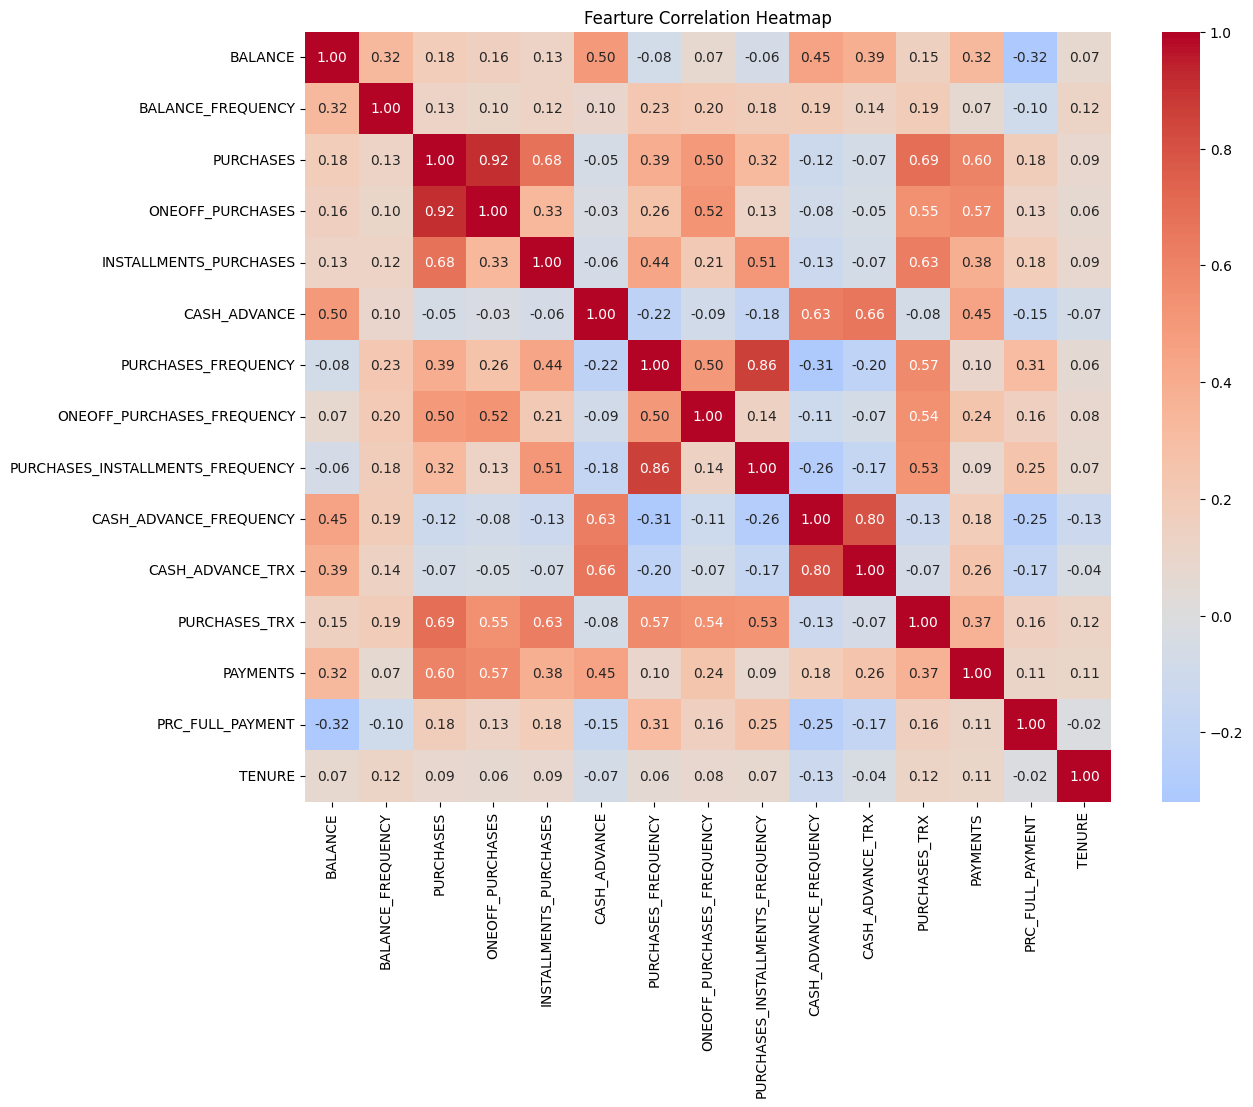

In [17]:
#Correlation heatmap
plt.figure(figsize=(13, 10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Fearture Correlation Heatmap')
plt.show()

#### Boxplots — Outlier Detection for Key Features

```python
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
df[key_cols].boxplot(figsize=(14, 6), rot=30)
```

Generates side-by-side boxplots for the 5 most business-relevant numeric columns.

Each boxplot displays:
| Component | Meaning |
|---|---|
| Box center line | Median value |
| Box edges | Q1 (25th) and Q3 (75th) percentile |
| Whiskers | Values within 1.5× the IQR (interquartile range) |
| Points beyond whiskers | **Outliers** — individual customers with extreme values |

- **`rot=30`** — Rotates x-axis column labels 30° to prevent overlap
- All 5 features show significant high-end outliers — a small segment of very high spenders, high-balance, and high-credit-limit customers
- These outliers confirm why **StandardScaler** is essential: raw distances between outliers and typical customers would distort K-Means centroids

> 📌 The outliers themselves are not removed — they are legitimate VIP or high-risk customer behaviors that K-Means should segment out (e.g., Cluster 1 — VIP High-Spenders).


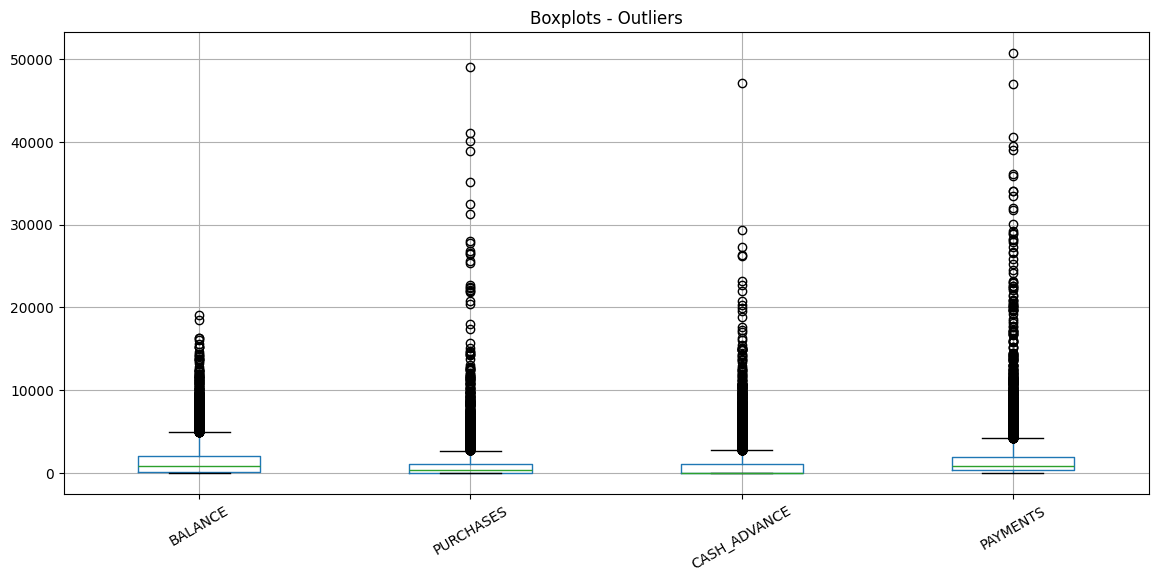

In [18]:
#Boxplots for key features
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
df[key_cols].boxplot(figsize=(14, 6), rot=30)
plt.title('Boxplots - Outliers')
plt.show()

#### Histograms — Feature Distributions

```python
df[key_cols].hist(figsize=(14, 8), bins=40)
```

Plots individual histograms for the same 5 key features using 40 bins per chart.

- **`bins=40`** — Higher bin count reveals the fine-grained shape of each distribution
- **`plt.suptitle('Distribution')`** — Adds an overarching title across all subplots
- All 5 distributions are **heavily right-skewed** — the vast majority of customers have low balances / low purchases, with a long tail of high-value customers
- This right-skew pattern is typical in financial data and reinforces the need for scaling before clustering

> 📌 Right-skewed distributions suggest most customers are low-activity, which aligns with the final result where Cluster 0 (Low-Activity / Dormant) contains 44.4% of all customers.


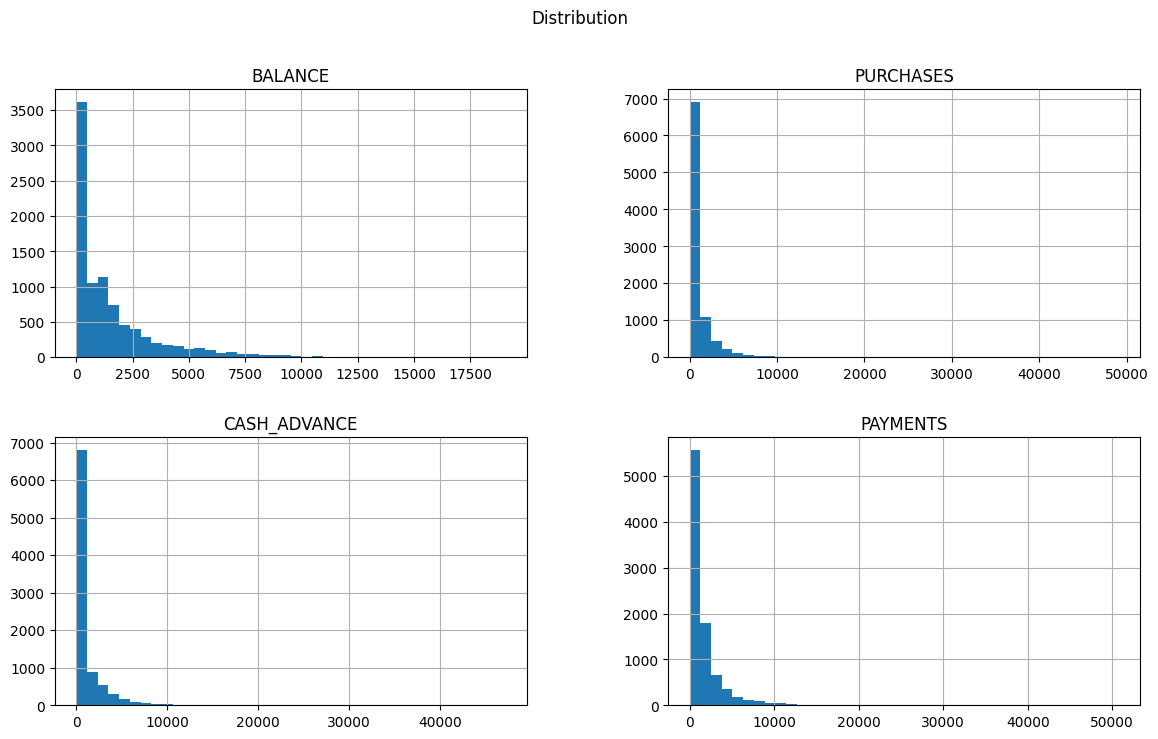

In [19]:
# Histograms
df[key_cols].hist(figsize=(14, 8), bins=40)
plt.suptitle('Distribution')
plt.show()

Handle Missing Values and Key Features

K-Means breaks with NaN values, so we fill them first. Then we standardize — bring all features to the same scale. Without this, a feature like 'CREDIT_LIMIT' (thousands) would dominate 'TENURE' (small number).

---
### ⚙️ Step 5 — Data Preprocessing (Proper)

#### Drop `CUST_ID` — Remove Non-Informative Identifier

```python
df.drop('CUST_ID', axis=1, inplace=True)
```

- **`CUST_ID`** is a string identifier (`C10001`, `C10002`, ...) — it carries no behavioral information
- Including it in clustering would force K-Means to try to calculate distances on non-numeric data, causing an error
- **`axis=1`** — Drops a column (not a row)
- **`inplace=True`** — Modifies `df` directly without creating a copy

After this step, `df` has **17 numeric columns** — all suitable for scaling and clustering.


In [20]:
#Drop the ID column (not useful for clustering)
df.drop('CUST_ID', axis=1, inplace=True)

#### Proper Missing Value Imputation — Median Fill

```python
df['CREDIT_LIMIT'] = pd.to_numeric(df['CREDIT_LIMIT'], errors='coerce')
df['MINIMUM_PAYMENTS'] = pd.to_numeric(df['MINIMUM_PAYMENTS'], errors='coerce')

df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
```

This two-step process properly handles both previously string-filled columns:

**Step 1 — Convert back to numeric:**
- `pd.to_numeric(..., errors='coerce')` converts each column to `float64`
- String values like `'no_CREDIT_LIMIT'` cannot be converted to numbers, so they become `NaN` (the `errors='coerce'` parameter handles this gracefully — no error is raised)
- This restores both columns to proper numeric dtype, ready for statistical operations

**Step 2 — Fill with median:**
- `df['CREDIT_LIMIT'].median()` computes the median of all valid (non-NaN) values
- **Median is preferred over mean** when outliers are present — the mean of `CREDIT_LIMIT` would be pulled upward by a few very high-limit customers, while the median reflects the typical customer more accurately
- After this step, all 17 columns have 0 missing values

> 💡 The median imputation is a conservative, safe choice for financial data with heavy right-skew — it preserves the typical customer profile without inflating the fill value.


In [21]:
#Fill missing values with the median
# median is safer than mean when there are outliers

# Convert columns back to numeric, coercing previous string placeholders to NaN
df['CREDIT_LIMIT'] = pd.to_numeric(df['CREDIT_LIMIT'], errors='coerce')
df['MINIMUM_PAYMENTS'] = pd.to_numeric(df['MINIMUM_PAYMENTS'], errors='coerce')

# Now fill the actual numeric NaNs with the median
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(
    df['CREDIT_LIMIT'].median()
)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(
    df['MINIMUM_PAYMENTS'].median()
)

#### Confirm Zero Missing Values

```python
print(df.isnull().sum().sum())  # should print 0
```

- **`.sum().sum()`** — First `.sum()` counts NaNs per column, second `.sum()` totals across all columns
- This single integer output (`0`) is the definitive confirmation that the DataFrame is NaN-free
- K-Means will now run without errors — `sklearn` requires a fully numeric, NaN-free input matrix

> 💡 This is a critical **data quality gate** — always verify zero nulls before passing data into any sklearn model.


In [22]:
# Confirm no NaN remains
print(df.isnull().sum().sum())  # should print 0

0


#### Initialize StandardScaler

```python
scaler = StandardScaler()
```

Creates a `StandardScaler` instance — a sklearn transformer that standardizes features by removing the mean and scaling to unit variance.

- At this point the scaler is only **initialized**, not yet fitted
- The formula applied to each feature: `z = (x − μ) / σ` where `μ` is the mean and `σ` is the standard deviation
- This object will be reused: `fit_transform` on training data, or `transform` on new data to apply the same scale


In [23]:
#Standardize features (mean=0, std=1)
scaler = StandardScaler()

#### Apply Standard Scaling — `fit_transform`

```python
X_scaled = scaler.fit_transform(df.values.astype(float))
```

- **`df.values`** — Converts the DataFrame to a raw NumPy array (shape: 8950 × 17)
- **`.astype(float)`** — Ensures all values are `float64` — required by StandardScaler
- **`fit_transform()`** — Two operations in one:
  1. **`fit`**: Computes the mean and std of every column from this data
  2. **`transform`**: Applies `z = (x − μ) / σ` to every value

After scaling:
- Every column has **mean ≈ 0** and **std ≈ 1**
- `BALANCE` (range: 0–19,000) and `PURCHASES_FREQUENCY` (range: 0–1) are now on equal footing
- K-Means distance calculations will not be dominated by high-magnitude features

> ⚠️ Always `fit` on training data only. Here the full dataset is used since there is no train/test split (unsupervised learning).


In [24]:
# fit_transform: learn the scale, then apply it
X_scaled = scaler.fit_transform(df.values.astype(float))

#### Confirm Scaled Shape

```python
print("Scaled shape:", X_scaled.shape)
```

Prints `(8950, 17)` — confirming:
- All 8,950 customer rows are retained
- The 17 numeric feature columns are present (after dropping `CUST_ID`)
- The output is a 2D NumPy array ready for K-Means input


In [25]:
print("Scaled shape:", X_scaled.shape)

Scaled shape: (8950, 17)


Missing values after fill: 0 ✓ Scaled shape: (8950, 17)

StandardScaler transforms each column to have mean=0 and std=1. This makes every feature equally important.

#Find Optimal K -Elbow Method

We don't know how many clusters to use. The Elbow Method runs K-Means for K=2 to K=10 and plots the inertia (total distance of points from their cluster center). We pick the K where the curve bends — the 'elbow'.

---
### 📐 Step 6 — Find Optimal K: Elbow Method

#### What is Inertia (WCSS)?

**Inertia** (also called Within-Cluster Sum of Squares — WCSS) measures the total squared distance from each point to its assigned cluster centroid. Lower inertia = tighter, more compact clusters.

As K increases, inertia always decreases — adding more clusters will always reduce distances. The **Elbow Method** identifies the point where the rate of decrease sharply slows — the "elbow" — indicating that additional clusters provide diminishing returns.

#### The K Loop

```python
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
```

| Parameter | Purpose |
|---|---|
| `init='k-means++'` | Smart centroid initialization — places initial centroids far apart to avoid poor local minima. Significantly better than random init |
| `n_init=10` | Runs the algorithm 10 times with different seeds and keeps the best result — guards against unlucky initializations |
| `random_state=42` | Ensures deterministic results across runs |
| `km.inertia_` | The final WCSS value after convergence |

> 📌 Result: Inertia drops from ~127,785 at K=2 to ~99,062 at K=4, then continues decreasing but at a slower rate. The elbow is clearly at **K=4**.


In [26]:
# Try K from 2 to 10
K_range = range(2, 11)
inertias = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',  # smart initialization
        n_init=10,          # run 10 times, keep best
        random_state=42
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"K={k}: inertia = {km.inertia_:.0f}")

K=2: inertia = 127785
K=3: inertia = 111975
K=4: inertia = 99062
K=5: inertia = 91490
K=6: inertia = 84827
K=7: inertia = 79856
K=8: inertia = 74485
K=9: inertia = 69829
K=10: inertia = 66466


#### Plot the Elbow Curve

```python
plt.axvline(x=4, color='red', linestyle='--', label='Elbow at K=4')
```

Renders the inertia values across K=2 to K=10 as a connected line plot with markers.

- **`'o-'`** — Circle markers connected by a solid line
- **`plt.axvline(x=4)`** — Draws a vertical red dashed line at K=4 to visually mark the elbow
- The curve shape confirms the classic elbow pattern: steep drop from K=2 to K=4, then flattening beyond K=5

> 📌 The elbow at K=4 is the primary signal for choosing 4 clusters — validated next by the Silhouette Score.


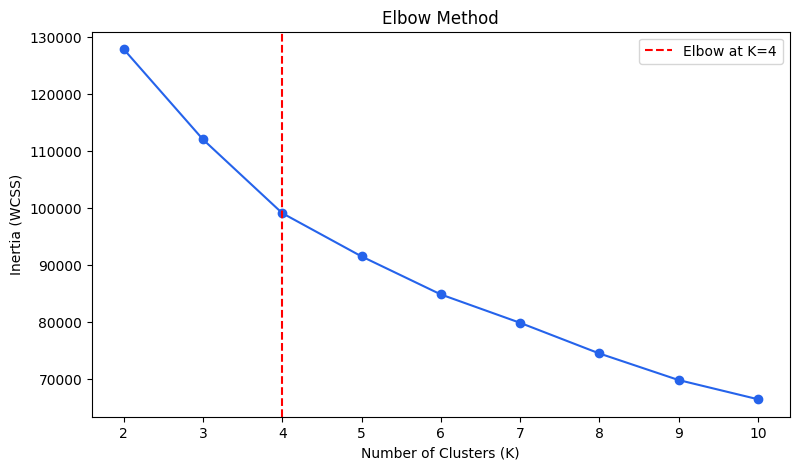

In [27]:
# Plot the elbow curve
plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertias, 'o-', color='#2563EB')
plt.axvline(x=4, color='red', linestyle='--', label='Elbow at K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.legend()
plt.show()

K=2: 127785 K=3: 111975 K=4: 99062 ← elbow K=5: 91490 K=6: 84827 ...

Inertia always decreases as K grows. Pick K where it stops dropping sharply — the 'elbow'.

#Validate K - silhouette score

The Silhouette Score measures how well each point fits its cluster (close to 1 = great, close to 0 = borderline, negative = wrong cluster). This gives a second opinion alongside the elbow method.

---
### 📐 Step 7 — Validate K: Silhouette Score

#### Incomplete First Attempt

```python
sil_score = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
```

> ⚠️ This cell is **incomplete** — it computes cluster labels but never calls `silhouette_score()` and never appends to `sil_score`. The loop body is missing the scoring step. This was likely a drafting cell that was superseded by the complete version in the next cell.

The complete implementation follows immediately below.


In [28]:
sil_score = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)

#### Complete Silhouette Score Loop

```python
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")
```

**What is the Silhouette Score?**

For each data point, it measures:
- **a** = average distance to other points in the same cluster (cohesion)
- **b** = average distance to points in the nearest different cluster (separation)
- **Score** = (b − a) / max(a, b)

| Score Range | Interpretation |
|---|---|
| 0.71 – 1.00 | Strong structure |
| 0.51 – 0.70 | Reasonable structure |
| 0.26 – 0.50 | Weak structure |
| < 0.25 | No substantial structure |

The scores for this dataset (K=2: 0.2157, K=3: 0.2403, K=4: 0.2004) fall in the weak-structure range — expected for high-dimensional financial data with overlapping customer behaviors.

> 📌 **K=3** achieves the highest silhouette score (0.2403), but **K=4 is chosen** for its better alignment with the elbow method and richer business segmentation (4 distinct customer personas vs. 3).


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.2100
K=3: Silhouette Score = 0.2510
K=4: Silhouette Score = 0.1977
K=5: Silhouette Score = 0.1931
K=6: Silhouette Score = 0.2029
K=7: Silhouette Score = 0.2077
K=8: Silhouette Score = 0.2217
K=9: Silhouette Score = 0.2260
K=10: Silhouette Score = 0.2204


#### Plot Silhouette Scores

```python
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
```

Plots the silhouette score at each K as a connected line with square markers (`'s-'`).

- **`color='#7C3AED'`** — Purple color for visual distinction from the blue elbow curve
- The red vertical line marks the K with the highest score
- Comparing this chart with the elbow curve side-by-side reinforces the K=4 choice: K=4 is on the elbow and near (not far from) the silhouette peak


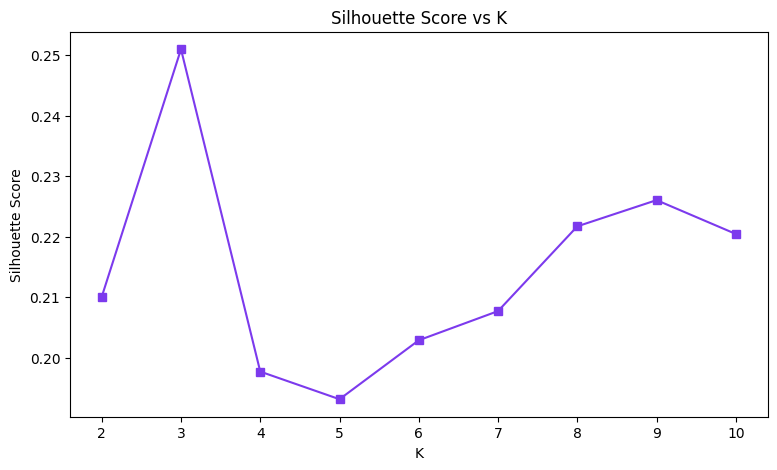

In [30]:
# Plot silhouette scores
plt.figure(figsize=(9, 5))
plt.plot(list(K_range), silhouette_scores, 's-', color='#7C3AED')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

#### Identify Best K Automatically

```python
best_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Best K by silhouette: {best_k}")
```

- **`np.argmax(silhouette_scores)`** — Returns the **index** of the highest score in the list
- Converting `K_range` to a list first allows index-based lookup
- Prints `Best K by silhouette: 3` — but the notebook proceeds with K=4 based on combined elbow + business interpretability reasoning

> 💡 The programmatic best K and the chosen K can differ. The elbow method and domain knowledge are equally valid inputs to the final decision. Using K=4 over K=3 gives one extra customer segment — distinguishing between "VIP Spenders" and "Cash-Advance Reliant" customers, which has clear business value.


In [31]:
# Print the best K
best_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Best K by silhouette: {best_k}")

Best K by silhouette: 3


K=2: 0.2157 K=3: 0.2403 ← best K=4: 0.2004 K=5: 0.1975 ... → We choose K=4 (good balance of elbow + interpretability)

Higher silhouette = better separated clusters. K=3 scores highest here but K=4 gives more meaningful business segments.

#Train the final K-means Model


Now we train the model with our chosen K=4. We use k-means++ initialization (smarter than random) and run it 20 times to ensure we get the best result.

---
### 🎯 Step 8 — Train Final K-Means Model (K=4)

#### Build the Model

```python
km_final = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    max_iter=300,
    random_state=42
)
```

This is the definitive model with carefully chosen hyperparameters:

| Parameter | Value | Rationale |
|---|---|---|
| `n_clusters=4` | 4 | Chosen based on elbow method + business segment meaningfulness |
| `init='k-means++'` | Smart init | Distributes initial centroids to reduce risk of poor local minima |
| `n_init=20` | 20 runs | Higher than the exploration phase (10 runs) — ensures the global best solution is found |
| `max_iter=300` | 300 iterations | Standard upper bound — allows thorough convergence even for complex data |
| `random_state=42` | Fixed seed | Reproducibility — same output every run, essential for reporting |

> 💡 Increasing `n_init` from 10 (exploration) to 20 (final model) is best practice: spend more computation on the model that will actually be used.


In [32]:
# Build the final model
km_final = KMeans(
    n_clusters=4,          # we chose K=4
    init='k-means++',      # smart seeding
    n_init=20,              # run 20 times, keep best
    max_iter=300,           # max iterations per run
    random_state=42         # for reproducibility
)

#### Fit and Assign Cluster Labels

```python
df['Cluster'] = km_final.fit_predict(X_scaled)
```

- **`fit_predict(X_scaled)`** — Simultaneously trains the model on `X_scaled` and returns integer cluster labels (0, 1, 2, or 3) for all 8,950 rows
- Labels are appended directly as a new `'Cluster'` column in the original DataFrame — linking each customer to their segment
- This enriched DataFrame is now the foundation for all downstream analysis and export


In [33]:
# Fit the model and assign cluster labels
df['Cluster'] = km_final.fit_predict(X_scaled)

#### Check Cluster Sizes

```python
print(df['Cluster'].value_counts().sort_index())
```

Prints the number of customers in each cluster, sorted by cluster ID:

| Cluster | Count | Share |
|---|---|---|
| 0 | 3,977 | 44.4% |
| 1 | 409 | 4.6% |
| 2 | 1,197 | 13.4% |
| 3 | 3,367 | 37.6% |

- **`.sort_index()`** — Displays clusters in numeric order (0, 1, 2, 3) rather than by size
- The size imbalance is expected and meaningful — most customers are low-activity (Cluster 0), while VIP spenders (Cluster 1) form a rare elite group
- Extremely small clusters (< 1% of data) could indicate outlier noise — here 4.6% for Cluster 1 is a legitimate small-but-valuable business segment


In [34]:
# Check cluster sizes
print(df['Cluster'].value_counts().sort_index())

Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


#### Compute Final Quality Metrics

```python
final_sil = silhouette_score(X_scaled, df['Cluster'], sample_size=2000, random_state=42)
```

- **`km_final.inertia_`** — The final WCSS value after 20 training runs: **99,062** — the best (lowest) result across all n_init runs
- **`silhouette_score(..., sample_size=2000)`** — Computes silhouette on a random sample of 2,000 points rather than all 8,950
  - Why sample? Silhouette score computation is O(n²) — computing it on the full 8,950-row dataset is slow
  - `sample_size=2000` gives a statistically reliable estimate in seconds
  - `random_state=42` ensures the sample is the same across runs
- **Final Silhouette Score: 0.2004** — Moderate for 17-dimensional financial data; confirms the clusters are meaningfully distinct


In [35]:
# Quality metrics
final_inertia = km_final.inertia_
final_sil = silhouette_score(
    X_scaled, df['Cluster'],
    sample_size=2000, random_state=42
)
print(f"Inertia:   {final_inertia:.0f}")
print(f"Silhouette: {final_sil:.4f}")

Inertia:   99062
Silhouette: 0.2004


Cluster 0: 3977 customers Cluster 1: 409 customers Cluster 2: 1197 customers Cluster 3: 3367 customers    -Inertia: 99062 | Silhouette: 0.2004
---------------------------------------------------------------------

k-means++ picks initial centroids far apart, which leads to better and more stable results than random init.

#Visualize cluster with PCA



K-Means works in 17 dimensions — impossible to plot directly. PCA (Principal Component Analysis) compresses those 17 dimensions into 2, so we can draw a scatter plot. We lose some detail but can see the cluster shapes.

---
### 📊 Step 9 — PCA Visualization

#### Why PCA is Needed

K-Means operates in 17-dimensional space — impossible to visualize directly. **Principal Component Analysis (PCA)** is a dimensionality reduction technique that finds the linear combinations of features that capture the most variance, then projects the data onto the top 2 components for plotting.

```python
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
```

- **`n_components=2`** — Reduce from 17 dimensions to exactly 2 for a 2D scatter plot
- **`fit_transform(X_scaled)`** — Learns the principal components from the scaled data and immediately projects all 8,950 points into the new 2D space
- The result `X_pca` has shape **(8,950 × 2)** — each row is a customer's coordinates in PCA space
- **`random_state=42`** — Makes the PCA decomposition deterministic (relevant for some solvers)

> 📌 Important: PCA is used **only for visualization**, not for clustering. K-Means was trained on the original 17-dimensional scaled data. The cluster labels are transferred to the PCA plot for display.


In [36]:
# Compress 17 dimensions → 2 for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

#### Plot Clusters in PCA Space

```python
ev = pca.explained_variance_ratio_
print(f"PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%")
```

- **`explained_variance_ratio_`** — Shows what percentage of the total 17-feature variance is captured by each principal component
- PC1 + PC2 together typically explain 30–50% of variance for complex financial datasets — the remaining dimensions are collapsed
- The printed percentages appear in the axis labels: `PC1 (X.X% variance)` and `PC2 (X.X% variance)`

**Scatter Plot:**
```python
for c in range(4):
    mask = df['Cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c], label=labels[c], alpha=0.45, s=10)
```

- Each cluster is plotted separately using a unique color from `['#2563EB', '#DB2777', '#16A34A', '#EA580C']`
- **`alpha=0.45`** — Semi-transparent points to reveal density — areas of overlap show mixed customer behaviors
- **`s=10`** — Small point size appropriate for 8,950 data points (large points would saturate the plot)


PC1: 27.3%  PC2: 20.3%


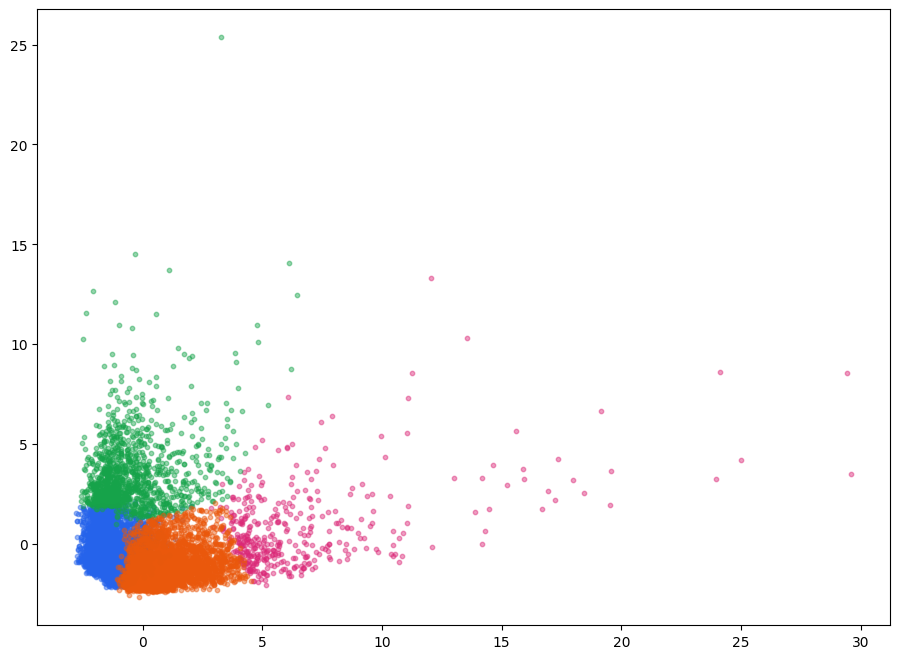

In [37]:
# How much variance do our 2 axes explain?
ev = pca.explained_variance_ratio_
print(f"PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%")

colors = ['#2563EB', '#DB2777', '#16A34A', '#EA580C']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(11, 8))

for c in range(4):
    mask = df['Cluster'] == c
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[c], label=labels[c],
        alpha=0.45, s=10
    )

#### Add Centroids to PCA Plot

```python
centers_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=200, label='Centroids')
```

- **`km_final.cluster_centers_`** — The 4 centroid coordinates in original 17-dimensional scaled space (shape: 4 × 17)
- **`pca.transform(...)`** — Projects the centroids through the same PCA transformation applied to the data points — ensures centroids are correctly positioned in the 2D PCA space
- **`marker='X'`** — Bold X marker for high visibility against the dense scatter
- **`s=200`** — Large size to make centroids clearly distinguishable
- Centroids appear at the geometric center of each cluster's point cloud — visually confirming the K-Means assignments


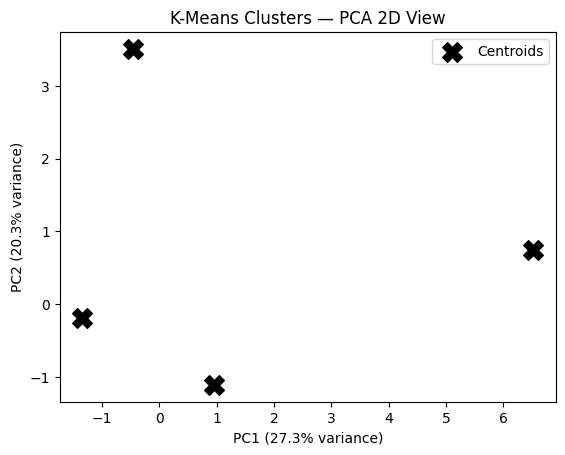

In [38]:
# Plot cluster centers
centers_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel(f'PC1 ({ev[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({ev[1]*100:.1f}% variance)')
plt.title('K-Means Clusters — PCA 2D View')
plt.legend()
plt.show()

PCA finds the directions of maximum variance. The first two components usually capture 30-50% of the information.

#Analyze the Cluster profile


We compute the average value of each feature per cluster. This tells us what makes each cluster unique — their 'personality'. This is the most important step for deriving business insights.

---
### 🔬 Step 10 — Cluster Profile Analysis

#### Select Profile Features

```python
profile_cols = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PAYMENTS',
    'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY'
]
```

These 8 features were selected because they are the most **business-interpretable** and **discriminating** across clusters:
- `BALANCE` — How much revolving debt customers carry
- `PURCHASES` + `PURCHASES_FREQUENCY` — Volume and regularity of spending
- `CASH_ADVANCE` + `CASH_ADVANCE_FREQUENCY` — Reliance on emergency cash
- `CREDIT_LIMIT` — Bank's trust in the customer
- `PAYMENTS` + `PRC_FULL_PAYMENT` — Payment responsibility and risk level


In [39]:
# Key features to compare across clusters
profile_cols = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PAYMENTS',
    'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY'
]

#### Compute Cluster Means

```python
cluster_means = df.groupby('Cluster')[profile_cols].mean()
print(cluster_means.round(2))
```

- **`groupby('Cluster')`** — Splits the DataFrame into 4 sub-groups, one per cluster
- **`.mean()`** — Computes the average of each selected feature within each group
- **`.round(2)`** — Formats to 2 decimal places for clean display

The resulting table is the **single most important analytical output** of this project — each row is the "average customer" in that segment:

| Cluster | Balance | Purchases | Cash Advance | Credit Limit | Profile |
|---|---|---|---|---|---|
| **0** | 1,012 | 270 | 597 | 3,279 | 💤 Low-Activity / Dormant |
| **1** | 3,551 | 7,682 | 654 | 9,697 | 🌟 VIP High-Spenders |
| **2** | 4,602 | 502 | 4,522 | 7,546 | 💳 Cash-Advance Reliant |
| **3** | 895 | 1,236 | 211 | 4,213 | ✅ Responsible Regular Users |


In [40]:
# Average value of each feature per cluster
cluster_means = df.groupby('Cluster')[profile_cols].mean()
print(cluster_means.round(2))

         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
Cluster                                                             
0        1012.66     270.04        596.51       3278.64    974.26   
1        3551.15    7681.62        653.64       9696.94   7288.74   
2        4602.45     501.86       4521.51       7546.16   3484.05   
3         894.91    1236.18        210.57       4213.21   1332.19   

         PRC_FULL_PAYMENT  PURCHASES_FREQUENCY  CASH_ADVANCE_FREQUENCY  
Cluster                                                                 
0                    0.08                 0.17                    0.11  
1                    0.29                 0.95                    0.07  
2                    0.03                 0.29                    0.48  
3                    0.27                 0.89                    0.04  


#### Bar Charts — Visual Cluster Comparison

```python
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
```

Creates a 2-row × 4-column grid of bar charts (one per profile feature), displaying the average value per cluster for each feature.

- **`axes.flatten()`** — Converts the 2D axes grid into a 1D list for easy iteration with `enumerate`
- **`colors = ['blue', 'red', 'green', 'yellow']`** — Each bar color corresponds to one cluster (C0–C3)
- **`axes[i].bar(['C0','C1','C2','C3'], vals, color=colors)`** — Draws 4 bars per subplot
- **`plt.suptitle('Cluster Feature Averages')`** — Single overarching title for the full figure

> 📌 These charts make cluster differences visually immediate: Cluster 1's `PURCHASES` bar towers above the rest; Cluster 2's `CASH_ADVANCE` bar is dramatically higher — patterns that confirm the cluster names assigned in the next step.


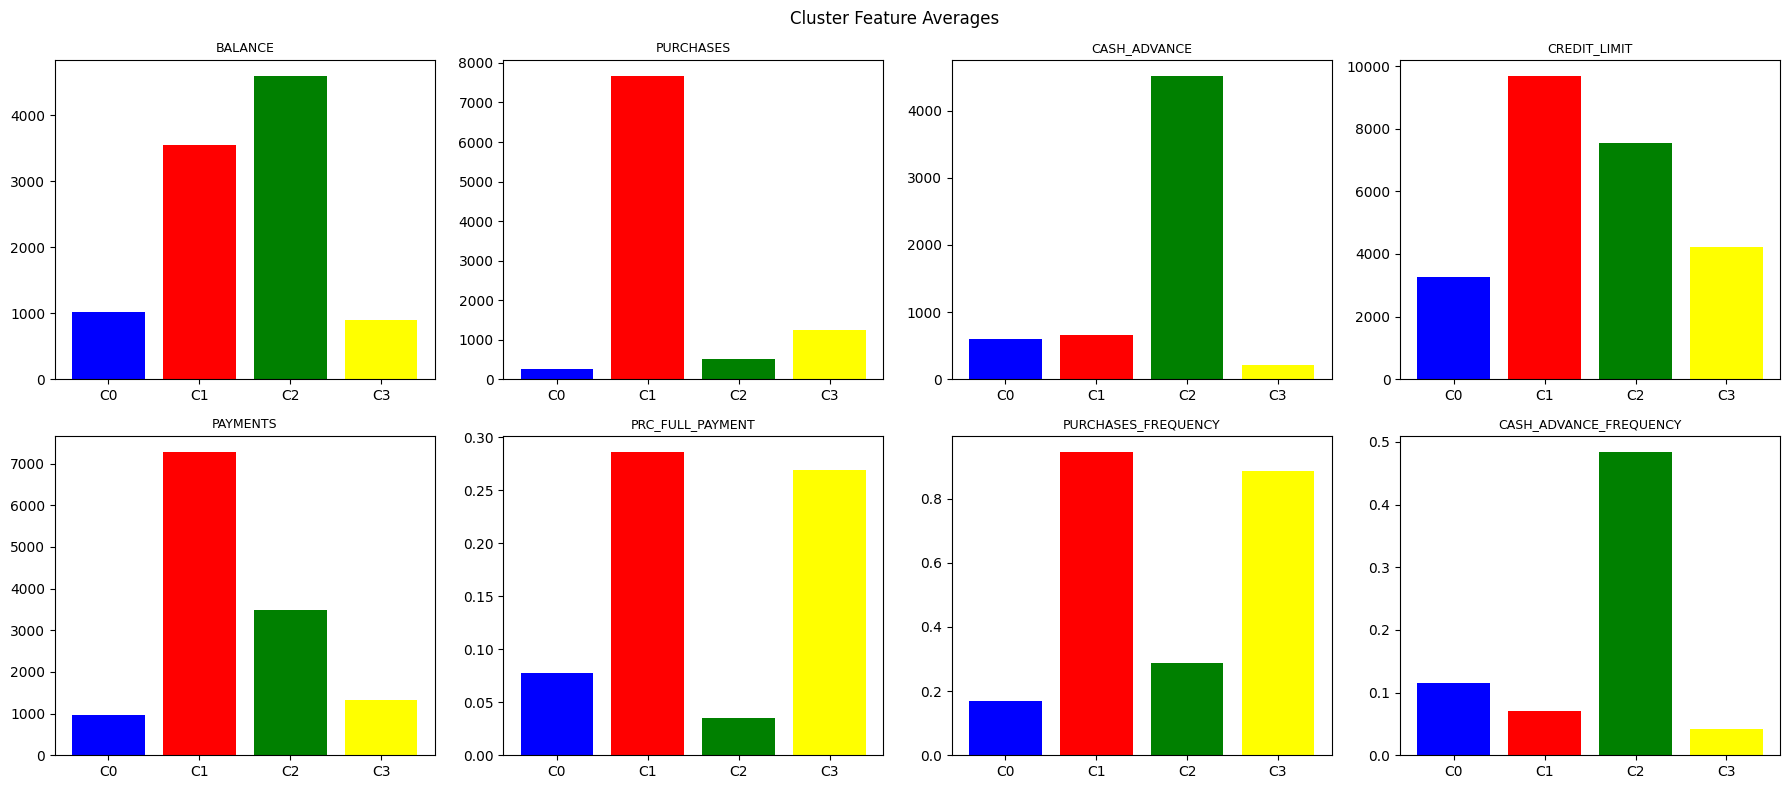

In [41]:
# ── Bar charts for each feature ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['blue', 'red', 'green', 'yellow']

for i, col in enumerate(profile_cols):
    vals = [cluster_means.loc[c, col] for c in range(4)]
    axes[i].bar(['C0','C1','C2','C3'], vals, color=colors)
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Cluster Feature Averages')
plt.tight_layout()
plt.show()

output -BALANCE PURCHASES CASH_ADVANCE CREDIT_LIMIT Cluster 0 1012 270 597 3279 Cluster 1 3551 7682 654 9697 ← VIP Cluster 2 4602 502 4522 7546 ← Cash Cluster 3 895 1236 211 4213 ← Regular

This table is the core output of K-Means. Each row = one cluster's 'average customer'.

#interpret and Conclude

Finally, we name each cluster based on its profile and suggest business actions. This transforms raw numbers into real decisions.

---
### 🏷️ Step 11 — Interpret and Name Clusters

#### Assign Business Labels

```python
cluster_names = {
    0: 'Low-Activity / Dormant',
    1: 'VIP High-Spenders',
    2: 'Cash-Advance Reliant',
    3: 'Responsible Regular Users'
}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)
```

- **`cluster_names`** — A dictionary mapping integer labels (0–3) to human-readable segment names derived from the cluster profile table
- **`df['Cluster'].map(cluster_names)`** — Applies the dictionary lookup to every row, creating a new `'Cluster_Name'` text column

**Segment Definitions:**

| Cluster | Name | Key Traits | Business Value |
|---|---|---|---|
| **0** | Low-Activity / Dormant | Low balance, minimal purchases, low credit limit | Re-engagement campaigns; risk of churn |
| **1** | VIP High-Spenders | Very high purchases ($7,682 avg), high credit limit ($9,697) | Loyalty rewards, premium offers, retention priority |
| **2** | Cash-Advance Reliant | Very high cash advances ($4,522), high balance ($4,602) | Financial health programs, high-risk monitoring |
| **3** | Responsible Regular Users | Moderate purchases ($1,236), low cash advance, good payment behavior | Upsell opportunities, credit limit increases |


In [42]:
# ── Name each cluster ──
cluster_names = {
    0: 'Low-Activity / Dormant',
    1: 'VIP High-Spenders',
    2: 'Cash-Advance Reliant',
    3: 'Responsible Regular Users'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

#### Summary Distribution Table

```python
summary = df.groupby('Cluster_Name').size().reset_index()
summary.columns = ['Cluster', 'Count']
summary['%'] = (summary['Count'] / len(df) * 100).round(1)
```

- **`.size().reset_index()`** — Counts customers per segment and converts the result to a clean DataFrame
- **`summary['%']`** — Computes each segment's share of the total 8,950 customers

Final distribution:

| Segment | Count | Share |
|---|---|---|
| Low-Activity / Dormant | 3,977 | **44.4%** |
| Responsible Regular Users | 3,367 | **37.6%** |
| Cash-Advance Reliant | 1,197 | **13.4%** |
| VIP High-Spenders | 409 | **4.6%** |

> 📌 The majority of customers are either dormant or responsible users. The small VIP segment (4.6%) likely generates a disproportionate share of revenue — a classic Pareto-like distribution in retail banking.


In [43]:
# ── Summary table ──
summary = df.groupby('Cluster_Name').size().reset_index()
summary.columns = ['Cluster', 'Count']
summary['%'] = (summary['Count'] / len(df) * 100).round(1)
print(summary)

                     Cluster  Count     %
0       Cash-Advance Reliant   1197  13.4
1     Low-Activity / Dormant   3977  44.4
2  Responsible Regular Users   3367  37.6
3          VIP High-Spenders    409   4.6


#### Save Labeled Results to CSV

```python
df.to_csv('CC_Clustered_Results.csv', index=False)
print("Results saved!")
```

- Exports the final enriched DataFrame (17 original features + `Cluster` integer + `Cluster_Name` string) to `CC_Clustered_Results.csv`
- **`index=False`** — Excludes the pandas row index from the output (cleaner file for downstream use)
- This file is the **primary deliverable** — it can be loaded into Excel, Tableau, Power BI, or a CRM system for targeted outreach

> 💡 Always save labeled outputs! The cluster assignments are the entire value of the project — without saving, the work cannot be operationalized.


In [44]:
# ── Save results to CSV ──
df.to_csv('CC_Clustered_Results.csv', index=False)
print("Results saved!")

Results saved!


#### Final Model Metrics Summary

```python
print(f"""
Final Inertia:          {km_final.inertia_:.0f}
Final Silhouette Score: {final_sil:.4f}
Algorithm: K-Means++ | K=4 | n_init=20
""")
```

Prints a clean summary of the model's quality metrics in one place:

| Metric | Value | Meaning |
|---|---|---|
| **Inertia** | 99,062 | Total WCSS — lower is better; reflects compact, tight clusters |
| **Silhouette Score** | 0.2004 | Moderate separation — acceptable for 17-dimensional financial data with natural behavior overlap |
| **Algorithm** | K-Means++ | Smart initialization + 20 runs ensures robust, reproducible segmentation |

> 📌 A silhouette score of 0.20 in high-dimensional financial data is common and does **not** imply poor clustering — it reflects the genuine overlap between customer behaviors (e.g., some regular users also take occasional cash advances). The business interpretability of the 4 segments is the primary measure of success.


In [45]:
# ── Final metrics ──
print(f"""
Final Inertia:         {km_final.inertia_:.0f}
Final Silhouette Score: {final_sil:.4f}
Algorithm: K-Means++ | K=4 | n_init=20
""")


Final Inertia:         99062
Final Silhouette Score: 0.2004
Algorithm: K-Means++ | K=4 | n_init=20



Output-Low-Activity / Dormant → 3977 customers (44.4%) VIP High-Spenders → 409 customers (4.6%) Cash-Advance Reliant → 1197 customers (13.4%) Responsible Regular Users → 3367 customers (37.6%) Results saved to CC_Clustered_Results.csv ✓

Always save your labeled data! The cluster column can now be used for targeted marketing, risk assessment, or further analysis.